100%|██████████| 28.7M/28.7M [00:00<00:00, 185MB/s]

Extracting files...


Dataset Path:
/root/.cache/kagglehub/datasets/START-UMD/gtd/versions/3

CSV Files Found:
['globalterrorismdb_0718dist.csv']

Dataset Loaded Successfully

First 5 Records
        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  197000000001   1970       7     2        NaN         0        NaN       58   
1  197000000002   1970       0     0        NaN         0        NaN      130   
2  197001000001   1970       1     0        NaN         0        NaN      160   
3  197001000002   1970       1     0        NaN         0        NaN       78   
4  197001000003   1970       1     0        NaN         0        NaN      101   

          country_txt  region  ... addnotes scite1 scite2  scite3  dbsource  \
0  Dominican Republic       2  ...      NaN    NaN    NaN     NaN      PGIS   
1              Mexico       1  ...      NaN    NaN    NaN     NaN      PGIS   
2         Philippines       5  ...      NaN    NaN    NaN     NaN      PGIS   
3              Greece      

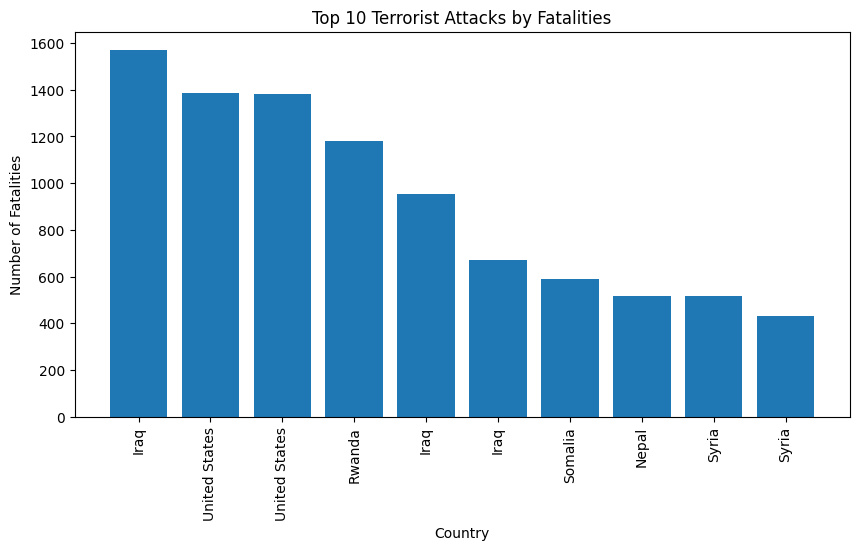


Mean Fatalities =
2.4032722986614385

Median Fatalities =
0.0

Mode Fatalities =
0    0.0
Name: nkill, dtype: float64

Standard Deviation =
11.545740560321697

Minimum Fatalities =
0.0

Maximum Fatalities =
1570.0

Descriptive Statistics
               iyear          nkill         nwound
count  181691.000000  171378.000000  165380.000000
mean     2002.638997       2.403272       3.167668
std        13.259430      11.545741      35.949392
min      1970.000000       0.000000       0.000000
25%      1991.000000       0.000000       0.000000
50%      2009.000000       0.000000       0.000000
75%      2014.000000       2.000000       2.000000
max      2017.000000    1570.000000    8191.000000

Average Fatalities by Region
region_txt
Sub-Saharan Africa             4.918492
Central America & Caribbean    3.578659
Middle East & North Africa     2.855584
South Asia                     2.300770
Central Asia                   1.788909
South America                  1.666994
East Asia            

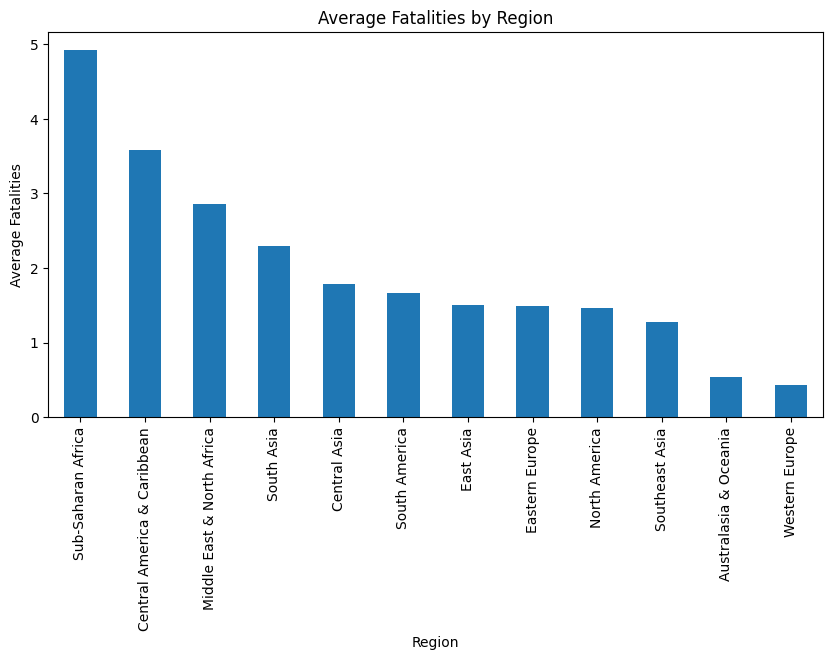


Regional Aggregation
                                nkill     nwound   success
region_txt                                                
Australasia & Oceania        0.543478   0.948905  0.851064
Central America & Caribbean  3.578659   1.141859  0.964714
Central Asia                 1.788909   3.619820  0.896980
East Asia                    1.509830  12.170410  0.847880
Eastern Europe               1.489554   2.462183  0.862558
Middle East & North Africa   2.855584   4.567714  0.878056
North America                1.461790   6.456072  0.837384
South America                1.666994   0.976671  0.928443
South Asia                   2.300770   3.281185  0.875372
Southeast Asia               1.280776   2.184064  0.893152
Sub-Saharan Africa           4.918492   3.660964  0.927464
Western Europe               0.425637   1.297473  0.851073

Correlation Matrix
            eventid     iyear    imonth      iday  extended   country  \
eventid    1.000000  0.999996  0.002706  0.018336  0.091761

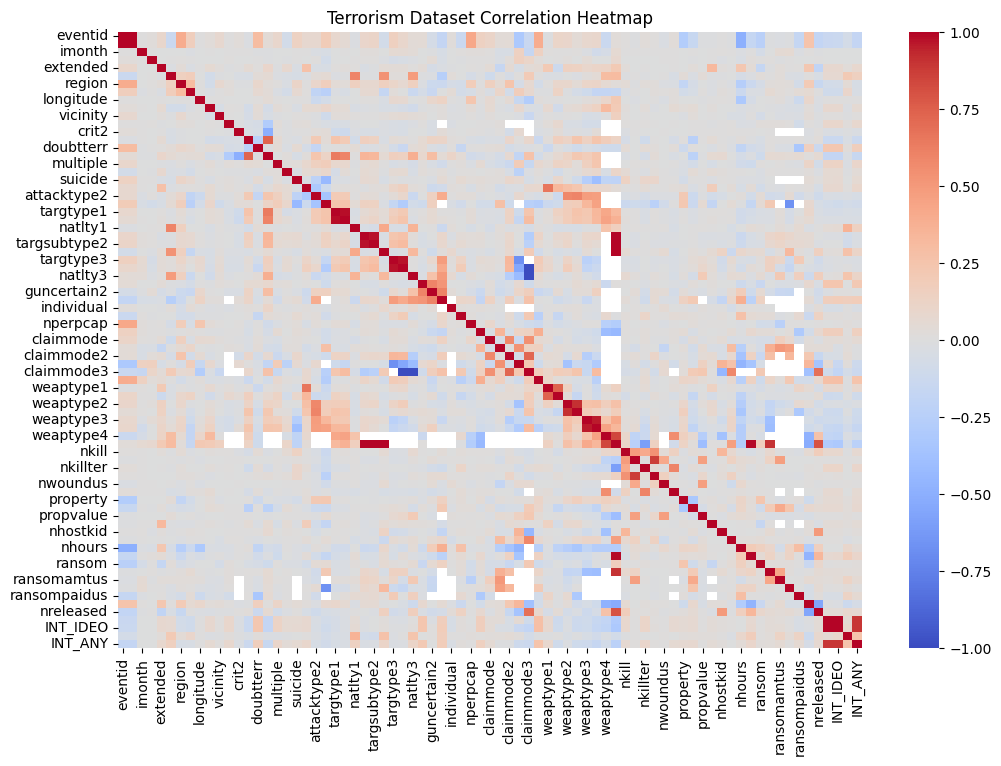

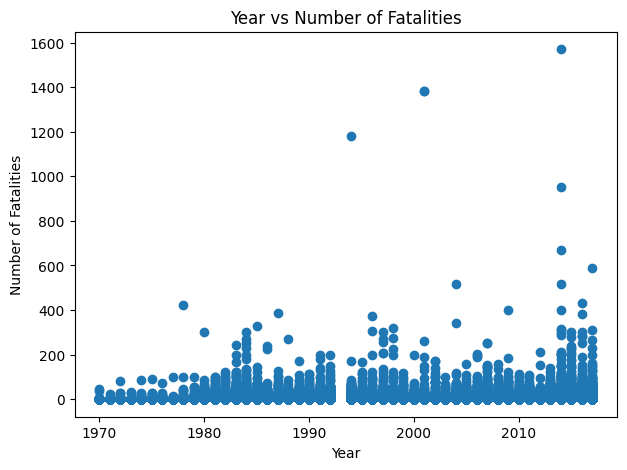

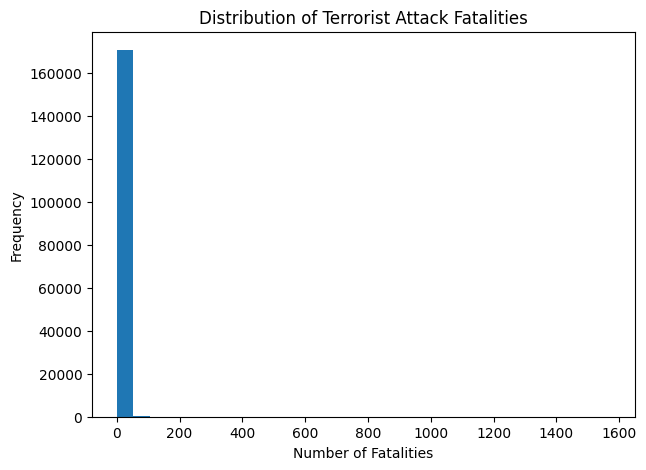

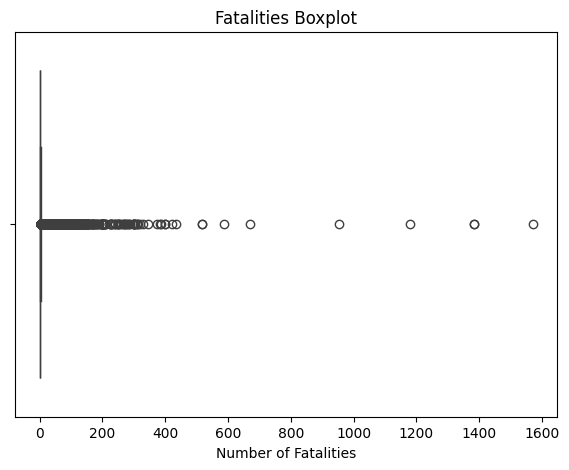


Attack Type Counts
attacktype1_txt
Bombing/Explosion                      88255
Armed Assault                          42669
Assassination                          19312
Hostage Taking (Kidnapping)            11158
Facility/Infrastructure Attack         10356
Unknown                                 7276
Unarmed Assault                         1015
Hostage Taking (Barricade Incident)      991
Hijacking                                659
Name: count, dtype: int64

Unique Countries
['Dominican Republic' 'Mexico' 'Philippines' 'Greece' 'Japan'
 'United States' 'Uruguay' 'Italy' 'East Germany (GDR)' 'Ethiopia'
 'Guatemala' 'Venezuela' 'West Germany (FRG)' 'Switzerland' 'Jordan'
 'Spain' 'Brazil' 'Egypt' 'Argentina' 'Lebanon' 'Ireland' 'Turkey'
 'Paraguay' 'Iran' 'United Kingdom' 'Colombia' 'Bolivia' 'Nicaragua'
 'Netherlands' 'Belgium' 'Canada' 'Australia' 'Pakistan' 'Zambia' 'Sweden'
 'Costa Rica' 'South Yemen' 'Cambodia' 'Israel' 'Poland' 'Taiwan' 'Panama'
 'Kuwait' 'West Bank and Gaza S

In [ ]:
# ============================================================
# EXPERIMENT 4
# DATA INSPECTION, FILTERING, STATISTICAL ANALYSIS, CORRELATION
# GLOBAL TERRORISM DATABASE
# ============================================================

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============================================================
# LOAD DATASET FROM KAGGLE
# ============================================================

path = kagglehub.dataset_download("START-UMD/gtd")

print("Dataset Path:")
print(path)

# Find CSV file automatically
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

print("\nCSV Files Found:")
print(csv_files)

csv_file = csv_files[0]

# Load Dataset
df = pd.read_csv(
    os.path.join(path, csv_file),
    encoding="latin1",
    low_memory=False
)

print("\nDataset Loaded Successfully")

# ============================================================
# PROGRAM 1 - DATA INSPECTION
# ============================================================

print("\nFirst 5 Records")
print(df.head())

print("\nLast 5 Records")
print(df.tail())

# ============================================================
# PROGRAM 2 - SHAPE
# ============================================================

print("\nShape of Dataset")
print(df.shape)

print("\nRows =", df.shape[0])
print("Columns =", df.shape[1])

# ============================================================
# PROGRAM 3 - DATA TYPES
# ============================================================

print("\nData Types")
print(df.dtypes)

print("\nDataset Info")
df.info()

# ============================================================
# PROGRAM 4 - FILTERING
# Number of Fatalities > 10
# ============================================================

high_fatality = df[df["nkill"] > 10]

print("\nAttacks with More Than 10 Fatalities")
print(
    high_fatality[
        [
            "iyear",
            "country_txt",
            "city",
            "attacktype1_txt",
            "nkill"
        ]
    ].head(10)
)

# ============================================================
# PROGRAM 5 - FILTER SUCCESSFUL ATTACKS
# ============================================================

successful = df[df["success"] == 1]

print("\nSuccessful Attacks")
print(
    successful[
        [
            "iyear",
            "country_txt",
            "attacktype1_txt",
            "success"
        ]
    ].head(10)
)

# ============================================================
# PROGRAM 6 - SORTING
# Sort by Number of Fatalities
# ============================================================

sorted_df = df.sort_values(
    by="nkill",
    ascending=False
)

print("\nTop Fatality Attacks")

print(
    sorted_df[
        [
            "iyear",
            "country_txt",
            "city",
            "attacktype1_txt",
            "nkill",
            "nwound"
        ]
    ].head(10)
)

# ============================================================
# BAR CHART
# TOP 10 ATTACKS BY FATALITIES
# ============================================================

top10 = sorted_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top10)),
    top10["nkill"].fillna(0)
)

plt.xticks(
    range(len(top10)),
    top10["country_txt"],
    rotation=90
)

plt.xlabel("Country")

plt.ylabel("Number of Fatalities")

plt.title("Top 10 Terrorist Attacks by Fatalities")

plt.show()

# ============================================================
# PROGRAM 7 - STATISTICAL ANALYSIS
# ============================================================

print("\nMean Fatalities =")
print(df["nkill"].mean())

print("\nMedian Fatalities =")
print(df["nkill"].median())

print("\nMode Fatalities =")
print(df["nkill"].mode())

print("\nStandard Deviation =")
print(df["nkill"].std())

print("\nMinimum Fatalities =")
print(df["nkill"].min())

print("\nMaximum Fatalities =")
print(df["nkill"].max())

# ============================================================
# PROGRAM 8 - DESCRIPTIVE STATISTICS
# ============================================================

print("\nDescriptive Statistics")

print(
    df[
        [
            "iyear",
            "nkill",
            "nwound"
        ]
    ].describe()
)

# ============================================================
# PROGRAM 9 - GROUPING
# Average Fatalities by Region
# ============================================================

group = df.groupby(
    "region_txt"
)["nkill"].mean().sort_values(ascending=False)

print("\nAverage Fatalities by Region")

print(group)

# Visualization

group.plot(
    kind="bar",
    figsize=(10,5)
)

plt.xlabel("Region")

plt.ylabel("Average Fatalities")

plt.title("Average Fatalities by Region")

plt.xticks(rotation=90)

plt.show()

# ============================================================
# PROGRAM 10 - AGGREGATION
# ============================================================

summary = df.groupby("region_txt").agg({

    "nkill": "mean",

    "nwound": "mean",

    "success": "mean"

})

print("\nRegional Aggregation")

print(summary)

# ============================================================
# PROGRAM 11 - CORRELATION
# ============================================================

numeric = df.select_dtypes(
    include=np.number
)

corr = numeric.corr()

print("\nCorrelation Matrix")

print(corr)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm"
)

plt.title("Terrorism Dataset Correlation Heatmap")

plt.show()

# ============================================================
# PROGRAM 12 - SCATTER PLOT
# Year vs Fatalities
# ============================================================

plt.figure(figsize=(7,5))

plt.scatter(
    df["iyear"],
    df["nkill"].fillna(0)
)

plt.xlabel("Year")

plt.ylabel("Number of Fatalities")

plt.title("Year vs Number of Fatalities")

plt.show()

# ============================================================
# PROGRAM 13 - HISTOGRAM
# Fatalities Distribution
# ============================================================

plt.figure(figsize=(7,5))

plt.hist(
    df["nkill"].dropna(),
    bins=30
)

plt.xlabel("Number of Fatalities")

plt.ylabel("Frequency")

plt.title("Distribution of Terrorist Attack Fatalities")

plt.show()

# ============================================================
# PROGRAM 14 - BOXPLOT
# ============================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    x=df["nkill"].dropna()
)

plt.title("Fatalities Boxplot")

plt.xlabel("Number of Fatalities")

plt.show()

# ============================================================
# PROGRAM 15 - VALUE COUNTS
# ============================================================

print("\nAttack Type Counts")

print(
    df["attacktype1_txt"].value_counts()
)

# ============================================================
# PROGRAM 16 - UNIQUE VALUES
# ============================================================

print("\nUnique Countries")

print(
    df["country_txt"].unique()
)

print("\nUnique Regions")

print(
    df["region_txt"].unique()
)

print("\nUnique Attack Types")

print(
    df["attacktype1_txt"].unique()
)

# ============================================================
# PROGRAM 17 - TOP 10 COUNTRIES BY ATTACKS
# ============================================================

print("\nTop 10 Countries by Number of Attacks")

country_counts = (
    df["country_txt"]
    .value_counts()
    .head(10)
)

print(country_counts)

# ============================================================
# PROGRAM 18 - ATTACKS BY YEAR
# ============================================================

print("\nNumber of Attacks by Year")

year_counts = (
    df["iyear"]
    .value_counts()
    .sort_index()
)

print(year_counts)

# ============================================================
# PROGRAM 19 - TOP 10 COUNTRIES BY FATALITIES
# ============================================================

print("\nTop 10 Countries by Fatalities")

country_fatalities = (
    df.groupby("country_txt")["nkill"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_fatalities)

# ============================================================
# PROGRAM 20 - MOST COMMON ATTACK TYPES
# ============================================================

print("\nMost Common Attack Types")

attack_types = (
    df["attacktype1_txt"]
    .value_counts()
    .head(10)
)

print(attack_types)

# ============================================================
# PROGRAM 21 - EXPORT DATA
# ============================================================

df.to_csv(
    "terrorism_data.csv",
    index=False
)

df.to_excel(
    "terrorism_data.xlsx",
    index=False
)

df.to_json(
    "terrorism_data.json",
    orient="records",
    indent=4
)

print("\nCSV, Excel and JSON files exported successfully.")

# ============================================================
# FINAL REPORT
# ============================================================

print("\n==============================================")

print("EXPERIMENT COMPLETED SUCCESSFULLY")

print("==============================================")

print("Dataset Shape :", df.shape)

print(
    "Missing Values :",
    df.isnull().sum().sum()
)

print(
    "Total Attacks :",
    len(df)
)

print(
    "Total Fatalities :",
    df["nkill"].sum()
)

print(
    "Total Wounded :",
    df["nwound"].sum()
)

print(
    "Number of Countries :",
    df["country_txt"].nunique()
)

print(
    "Number of Attack Types :",
    df["attacktype1_txt"].nunique()
)

print("Correlation Matrix Generated")

print("==============================================")